In [ ]:
!pip install xgboost

In [ ]:
import zipfile
import os

with zipfile.ZipFile('secom.zip', 'r') as zip_ref:
    zip_ref.extractall('secom_dataset')

print("Unzipped successfully")

os.listdir('secom_dataset')

Unzipped successfully


['secom.names', 'secom_labels.data', 'secom.data']

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer

import xgboost as xgb

In [ ]:
data = pd.read_csv(
    "secom_dataset/secom.data",
    sep="\s+",
    header=None
)

labels = pd.read_csv(
    "secom_dataset/secom_labels.data",
    sep="\s+",
    header=None
)
print(data.shape)
print(labels.shape)

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_173/809426345.py:3: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",
/tmp/ipykernel_173/809426345.py:9: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


(1567, 590)
(1567, 2)


In [ ]:
y = labels[0]
y = y.replace(-1,0)

In [ ]:
data.head()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [ ]:
data.describe()

,0,1,2,3,4,5,6,7,8,9,...,580,581,582,583,584,585,586,587,588,589
count,1561.000000,1560.000000,1553.000000,1553.000000,1553.000000,1553.0,1553.000000,1558.000000,1565.000000,1565.000000,...,618.000000,618.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000,1566.000000
mean,3014.452896,2495.850231,2200.547318,1396.376627,4.197013,100.0,101.112908,0.121822,1.462862,-0.000841,...,0.005396,97.934373,0.500096,0.015318,0.003847,3.067826,0.021458,0.016475,0.005283,99.670066
std,73.621787,80.407705,29.513152,441.691640,56.355540,0.0,6.237214,0.008961,0.073897,0.015116,...,0.003116,87.520966,0.003404,0.017180,0.003720,3.578033,0.012358,0.008808,0.002867,93.891919
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400,...,0.001000,0.000000,0.477800,0.006000,0.001700,1.197500,-0.016900,0.003200,0.001000,0.000000
25%,2966.260000,2452.247500,2181.044400,1081.875800,1.017700,100.0,97.920000,0.121100,1.411200,-0.010800,...,0.003400,46.184900,0.497900,0.011600,0.003100,2.306500,0.013425,0.010600,0.003300,44.368600
50%,3011.490000,2499.405000,2201.066700,1285.214400,1.316800,100.0,101.512200,0.122400,1.461600,-0.001300,...,0.004700,72.288900,0.500200,0.013800,0.003600,2.757650,0.020500,0.014800,0.004600,71.900500
75%,3056.650000,2538.822500,2218.055500,1591.223500,1.525700,100.0,104.586700,0.123800,1.516900,0.008400,...,0.006475,116.539150,0.502375,0.016500,0.004100,3.295175,0.027600,0.020300,0.006400,114.749700
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900,...,0.028600,737.304800,0.509800,0.476600,0.104500,99.303200,0.102800,0.079900,0.028600,737.304800


In [ ]:
missing = data.isnull().sum()
missing = missing[missing > 0]

print("Features with missing values:", len(missing))

Features with missing values: 538


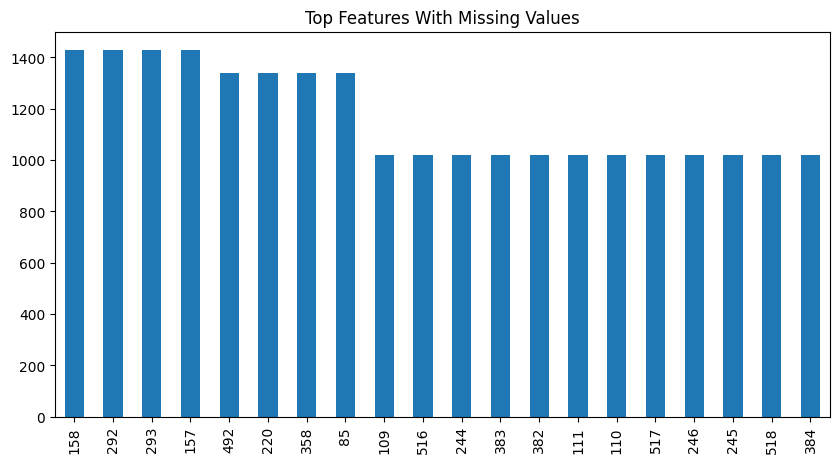

In [ ]:
import matplotlib.pyplot as plt

missing.sort_values(ascending=False).head(20).plot(kind="bar", figsize=(10,5))
plt.title("Top Features With Missing Values")
plt.show()

In [ ]:
threshold = len(data) * 0.5

data_clean = data.dropna(thresh=threshold, axis=1)

print("New shape:", data_clean.shape)

New shape: (1567, 562)


In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = imputer.fit_transform(data_clean)

In [ ]:
print(y.value_counts())

0
0    1463
1     104
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X = selector.fit_transform(X)

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
model = CatBoostClassifier(
    iterations=300,
    depth=5,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0
)

model.fit(X_train, y_train)


CatBoostClassifier(depth=5, iterations=300, learning_rate=0.05, loss_function='Logloss', verbose=0)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
print(confusion_matrix(y_test, y_pred))



[[293   0]
 [ 21   0]]


In [ ]:
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))



ROC AUC: 0.800422558101739


In [ ]:
train_pred = model.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

Train accuracy: 1.0
Test accuracy: 0.9331210191082803


In [ ]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print(y_train_bal.value_counts())

0
0    1170
1    1170
Name: count, dtype: int64


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train_bal)
X_test_pca = pca.transform(X_test)

In [ ]:
model = CatBoostClassifier(
    iterations=200,
    depth=4,
    learning_rate=0.05,
    loss_function='Logloss',
    verbose=0
)

model.fit(X_train_pca, y_train_bal)

CatBoostClassifier(depth=4, iterations=200, learning_rate=0.05, loss_function='Logloss', verbose=0)

In [ ]:
y_pred = model.predict(X_test_pca)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       293
           1       0.00      0.00      0.00        21

    accuracy                           0.91       314
   macro avg       0.47      0.49      0.48       314
weighted avg       0.87      0.91      0.89       314



In [ ]:
print(confusion_matrix(y_test, y_pred))
roc_auc_score(y_test, model.predict_proba(X_test_pca)[:,1])
train_pred = model.predict(X_train_pca)
print("Train accuracy:", accuracy_score(y_train_bal, train_pred))
print("Test accuracy:", accuracy_score(y_test, model.predict(X_test_pca)))

[[285   8]
 [ 21   0]]
Train accuracy: 0.9923076923076923
Test accuracy: 0.9076433121019108


In [ ]:
!pip install lightgbm

from lightgbm import LGBMClassifier

In [ ]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
)

model.fit(X_train_pca, y_train_bal)

[LightGBM] [Info] Number of positive: 1170, number of negative: 1170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001277 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12750
[LightGBM] [Info] Number of data points in the train set: 2340, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=300, subsample=0.8)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

y_pred = model.predict(X_test_pca)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test_pca)[:,1]))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       293
           1       0.00      0.00      0.00        21

    accuracy                           0.91       314
   macro avg       0.47      0.49      0.48       314
weighted avg       0.87      0.91      0.89       314

[[285   8]
 [ 21   0]]
Test Accuracy: 0.9076433121019108
ROC AUC: 0.5498130993011539


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


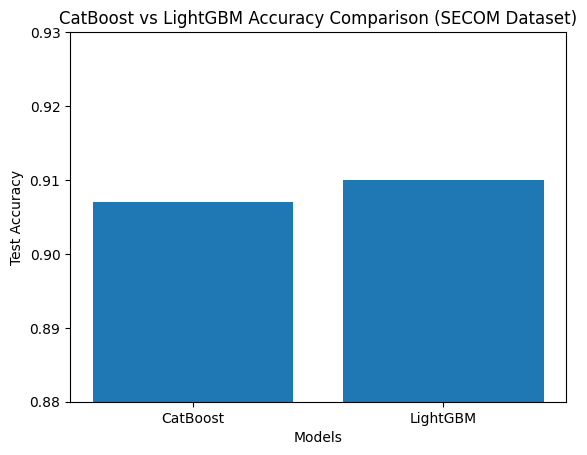

In [ ]:
import matplotlib.pyplot as plt

models = ['CatBoost', 'LightGBM']
accuracy = [0.907, 0.91]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Models")
plt.ylabel("Test Accuracy")
plt.title("CatBoost vs LightGBM Accuracy Comparison (SECOM Dataset)")

plt.ylim(0.88, 0.93)

plt.show()

In [ ]:
import joblib

# save the trained model
joblib.dump(model, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [ ]:
from google.colab import files

files.download("lightgbm_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>